<a href="https://colab.research.google.com/github/ram1014/colab_files/blob/main/NER_Ramon_Delgado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NER

Alumno: Ramon Humberto Delgado Andrade

Matrícula: 263165

Profesor: Rogelio Florencia Juare

In [ ]:
import pandas as pd
import nltk
from nltk.tag import hmm
import re
from sklearn.model_selection import train_test_split
import sklearn_crfsuite
from sklearn_crfsuite import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn_crfsuite.utils import flatten

In [ ]:
def group_sentence(df):
    sentence_list = []
    label_list = []
    grouped = df.groupby("Sentence #")

    for _,group in grouped:
        sentence = [(w,p) for w, p  in zip(group["Word"],group["Pos"])]
        label = group["Tag"].values
        sentence_list.append(sentence)
        label_list.append(label)
    return sentence_list,label_list

def word2features(sent,i):
    word, postag = sent[i]
    features = {
        "word.lower(),": word.lower(),
        "postag": postag,
        "is_title": word.istitle(),
        "is_upper": word.isupper(),
        "is_digit": word.isdigit()
    }
    if i > 0:
        prev_word, prev_pos = sent[i - 1]
        features.update({
            "-1:word.lower()": prev_word.lower(),
            "-1:postag": prev_pos
        })
    else:
        features["BOS"] = True

    if i < len(sent) -1:
        next_word, next_pos = sent[i + 1]
        features.update({
            "+1:word.lower()": next_word.lower(),
            "+1:postag": next_pos
        })
    else:
        features["EOS"] = True

    return features

def sent2features(sent):
    return [word2features(sent,i) for i in range(len(sent))]


In [ ]:
# Load the TSV file
df = pd.read_csv('split1.mx-news.txt', sep='\t')

display(df)

sentence_list,label_list = group_sentence(df)
print("="*50)
print("Sentence 1")
display(sentence_list[0])
print("="*50)
print("Labels from sentence 1")
display(label_list[0])



,Sentence #,Word,Pos,Tag
0,Sentence 1,Interesante,ADJ,O
1,Sentence 1,será,VLfin,O
2,Sentence 1,conocer,VLinf,O
3,Sentence 1,las,ART,O
4,Sentence 1,reflexiones,NC,O
...,...,...,...,...
49313,Sentence 1295,edificio,NC,O
49314,Sentence 1295,de,PDEL,O
49315,Sentence 1295,la,NC,O
49316,Sentence 1295,Cancillería,PREP,S-ORG


Sentence 1


[('Interesante', 'ADJ'),
 ('será', 'VLfin'),
 ('conocer', 'VLinf'),
 ('las', 'ART'),
 ('reflexiones', 'NC'),
 ('de', 'PREP'),
 ('Pedro', 'NP'),
 ('Kumamoto', 'NC'),
 ('en', 'PREP'),
 ('torno', 'NC'),
 ('a', 'PREP'),
 ('este', 'DM'),
 ('fracaso', 'NC'),
 (',', 'CM'),
 ('por', 'PREP'),
 ('el', 'ART'),
 ('momento', 'NC'),
 ('lo', 'ART'),
 ('único', 'NC'),
 ('que', 'CQUE'),
 ('ha', 'VHfin'),
 ('dicho', 'QU'),
 ('es', 'VSfin'),
 ('que', 'CQUE'),
 ('al', 'PAL'),
 ('interior', 'NC'),
 ('de', 'PREP'),
 ('su', 'PPO'),
 ('grupo', 'NC'),
 ('existen', 'VLfin'),
 ('dos', 'CARD'),
 ('planteamientos', 'NC'),
 (',', 'CM'),
 ('uno', 'CARD'),
 ('seguir', 'VLinf'),
 ('por', 'PREP'),
 ('la', 'ART'),
 ('ruta', 'NC'),
 ('independiente', 'ADJ'),
 (',', 'CM'),
 ('el', 'ART'),
 ('otro', 'QU'),
 ('destaca', 'VLfin'),
 ('las', 'ART'),
 ('bondades', 'NC'),
 ('de', 'CSUBI'),
 ('fundar', 'VLinf'),
 ('una', 'ART'),
 ('agrupación', 'NC'),
 ('o', 'CC'),
 ('un', 'ART'),
 ('partido', 'NC'),
 ('político', 'ADJ'),
 ('.', 

Labels from sentence 1


array(['O', 'O', 'O', 'O', 'O', 'O', 'B-PER', 'E-PER', 'O', 'O', 'O', 'O',
       'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O',
       'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O',
       'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O',
       'O', 'O', 'O'], dtype=object)

# Split to create tests

In [ ]:
sentence_train, sentence_test, label_train, label_test = train_test_split(
    sentence_list, label_list, test_size=0.20, random_state=42
)
print("Sentences for train: ", len(sentence_train))
print("Labels for train: ", len(label_train))
print("Sentences for test: ", len(sentence_test))
print("Labels for test: ", len(label_test))


Sentences for train:  1036
Labels for train:  1036
Sentences for test:  259
Labels for test:  259


# Prepare sentences using the feature creator

In [ ]:
# -----------------------------
# Usar el creador de features para entrenar los modelos
# -----------------------------
X_train = [sent2features(s) for s in sentence_train]
y_train = label_train
X_test = [sent2features(s) for s in sentence_test]
y_test = label_test

#display(X_train[0])
#display(X_test[0])


# Entrenar CRF

In [ ]:
# -----------------------------
# Entrenar CRF
# -----------------------------
crf = sklearn_crfsuite.CRF(
    algorithm="lbfgs",
    max_iterations=100,
    all_possible_transitions=True
)
crf.fit(X_train, y_train)

,algorithm,'lbfgs'
,min_freq,None
,all_possible_states,None
,all_possible_transitions,True
,c1,None
,c2,None
,max_iterations,100
,num_memories,None
,epsilon,None
,period,None
,delta,None


# Evaluar el modelo

In [ ]:
y_pred = crf.predict(X_test)

print("=== Reporte de clasificación (test) ===")
print(metrics.flat_classification_report(y_test, y_pred, digits=3))

#skipping printing this for final document
#for x, yt, yp in zip(X_test, y_test, y_pred):
    #print("X_test: ")
    #for xi in x:
        #print(xi)

    #print("y_test: ")
    #print(yt[0:1])

    #print("y_pred: ")
    #print(yp[0:1])

=== Reporte de clasificación (test) ===
              precision    recall  f1-score   support

       B-ADD      0.875     0.636     0.737        11
       B-AGE      1.000     0.750     0.857         8
       B-DAT      0.921     0.891     0.906        92
       B-DOC      1.000     0.235     0.381        17
       B-EVT      0.778     0.412     0.538        17
       B-FAC      1.000     0.455     0.625        11
       B-GPE      0.880     0.667     0.759        33
       B-LOC      1.000     0.500     0.667         2
       B-MNY      1.000     0.833     0.909        12
       B-ORG      0.764     0.773     0.768        88
       B-PER      0.838     0.915     0.875       153
       B-PEX      1.000     0.571     0.727        14
       B-PRC      1.000     0.600     0.750         5
       B-PRO      1.000     0.222     0.364         9
       B-TIM      1.000     0.783     0.878        23
       B-TIT      0.767     0.524     0.623        63
       E-ADD      0.875     0.636     0.7

/home/humberto/.conda/envs/pydata-book/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/humberto/.conda/envs/pydata-book/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/humberto/.conda/envs/pydata-book/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

# Matriz de confusion

In [ ]:
# Crear el arreglo plano
y_test_flat = flatten(y_test)
y_pred_flat = flatten(y_pred)

labels = list(set(y_test_flat))
print(labels)

# Calcular la matriz de confusión
cm = confusion_matrix(y_test_flat, y_pred_flat, labels=labels)

['S-ORG', 'E-ORG', 'E-FAC', 'I-TIM', 'B-FAC', 'E-DAT', 'S-TIT', 'S-ADD', 'B-EVT', 'B-TIT', 'E-ADD', 'E-LOC', 'B-DAT', 'I-PEX', 'E-PER', 'E-TIM', 'S-PEX', 'E-PRC', 'B-MNY', 'E-TIT', 'B-PRC', 'E-MNY', 'B-PEX', 'E-PRO', 'I-PER', 'I-LOC', 'I-ADD', 'I-GPE', 'B-AGE', 'S-DAT', 'E-AGE', 'I-ORG', 'B-DOC', 'S-EVT', 'E-PEX', 'E-EVT', 'S-GPE', 'I-PRO', 'B-TIM', 'S-PRO', 'I-DAT', 'B-ORG', 'B-ADD', 'B-GPE', 'I-DOC', 'B-PER', 'B-LOC', 'I-PRC', 'S-TIM', 'E-DOC', 'I-MNY', 'O', 'S-DEM', 'S-PER', 'B-PRO', 'S-FAC', 'I-EVT', 'I-TIT', 'I-FAC', 'E-GPE', 'S-DOC']


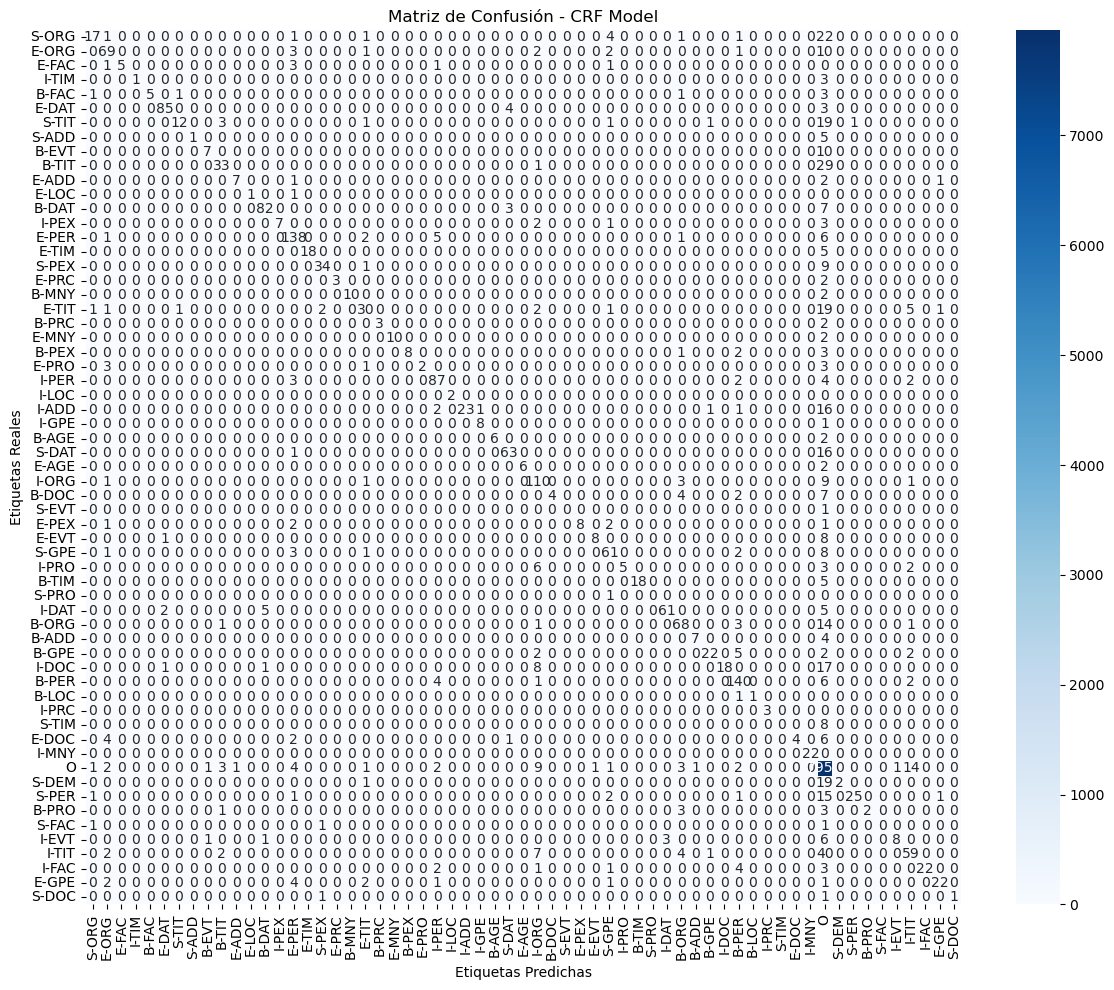

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,          # Muestra los números en cada celda
    fmt='d',             # Formato numérico entero
    cmap='Blues',        # Degradado de color azul
    xticklabels=labels,  # Etiquetas en el eje X (Predicciones)
    yticklabels=labels   # Etiquetas en el eje Y (Reales)
)

plt.title('Matriz de Confusión - CRF Model')
plt.ylabel('Etiquetas Reales')
plt.xlabel('Etiquetas Predichas')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Conclusiones

La etiqueta NER que considero fue de las que tuvo peor desempeñó fue "S-DEM" con un F1-Score de  0.167, existen tags que obtuvieron un score de 0.0, pero también hay que considerar que tienen pocas existencias en el corpus.
Por otro lado, B-AGE tuvo buenos resultado con pocas existencias en el corpus.